In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

df_raw = pd.read_csv("spotify-tracks-dataset.csv")
print("原始数据集行数：", df_raw.shape[0])
print(df_raw.columns.tolist())

原始数据集行数： 114000
['Unnamed: 0.1', 'Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']


In [2]:
# 1.复制原始数据
df = df_raw.copy()

# 2.筛选2026年前数据，本数据集没有release_year字段，改用全部数据，筛选我们需要用到的列
keep_cols = ['track_id','artists','track_name','popularity','duration_ms','danceability','energy','speechiness','acousticness','instrumentalness','liveness','valence','tempo','track_genre']
df = df[keep_cols]

# 3.删除空值
df = df.dropna()
print(f"清洗后数据行数：{df.shape[0]}")

# 4.查看流派有哪些
print("\n所有音乐流派：")
print(df['track_genre'].unique())

# 5.筛选K‑pop和pop，我们做k‑pop vs pop对比分析
df_kpop = df[df["track_genre"] == "k‑pop"]
df_pop = df[df["track_genre"] == "pop"]

print(f"\nK‑pop歌曲数量：{len(df_kpop)}")
print(f"Pop歌曲数量：{len(df_pop)}")

清洗后数据行数：113999

所有音乐流派：
['acoustic' 'afrobeat' 'alt-rock' 'alternative' 'ambient' 'anime'
 'black-metal' 'bluegrass' 'blues' 'brazil' 'breakbeat' 'british'
 'cantopop' 'chicago-house' 'children' 'chill' 'classical' 'club' 'comedy'
 'country' 'dance' 'dancehall' 'death-metal' 'deep-house' 'detroit-techno'
 'disco' 'disney' 'drum-and-bass' 'dub' 'dubstep' 'edm' 'electro'
 'electronic' 'emo' 'folk' 'forro' 'french' 'funk' 'garage' 'german'
 'gospel' 'goth' 'grindcore' 'groove' 'grunge' 'guitar' 'happy'
 'hard-rock' 'hardcore' 'hardstyle' 'heavy-metal' 'hip-hop' 'honky-tonk'
 'house' 'idm' 'indian' 'indie-pop' 'indie' 'industrial' 'iranian'
 'j-dance' 'j-idol' 'j-pop' 'j-rock' 'jazz' 'k-pop' 'kids' 'latin'
 'latino' 'malay' 'mandopop' 'metal' 'metalcore' 'minimal-techno' 'mpb'
 'new-age' 'opera' 'pagode' 'party' 'piano' 'pop-film' 'pop' 'power-pop'
 'progressive-house' 'psych-rock' 'punk-rock' 'punk' 'r-n-b' 'reggae'
 'reggaeton' 'rock-n-roll' 'rock' 'rockabilly' 'romance' 'sad' 'salsa'
 '

In [3]:
# 修正：使用普通短横线 k-pop
df_kpop = df[df["track_genre"] == "k-pop"]
df_pop = df[df["track_genre"] == "pop"]

print(f"K-pop歌曲数量：{len(df_kpop)}")
print(f"Pop歌曲数量：{len(df_pop)}")

K-pop歌曲数量：999
Pop歌曲数量：1000


In [4]:
# 合并两份数据，做对比
df_compare = pd.concat([df_kpop, df_pop])

# 计算两组各个音频特征的均值
stat_result = df_compare.groupby("track_genre")[
    ['danceability','energy','valence','acousticness','speechiness','instrumentalness']
].mean()

print("K‑pop 与 Pop 音频特征均值对比：")
print(stat_result.round(3))

K‑pop 与 Pop 音频特征均值对比：
             danceability  energy  valence  acousticness  speechiness  \
track_genre                                                             
k-pop               0.648   0.676    0.557         0.293        0.088   
pop                 0.630   0.606    0.506         0.344        0.080   

             instrumentalness  
track_genre                    
k-pop                   0.010  
pop                     0.009  


D:\anaconda\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


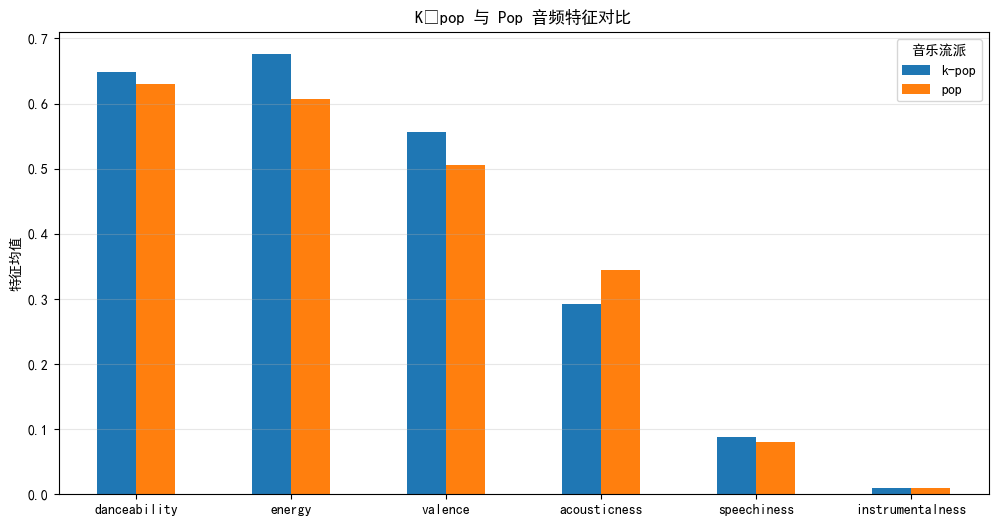

In [5]:
plt.figure(figsize=(12,6))
stat_result.T.plot(kind="bar", ax=plt.gca())
plt.title("K‑pop 与 Pop 音频特征对比")
plt.ylabel("特征均值")
plt.xticks(rotation=0)
plt.legend(title="音乐流派")
plt.grid(axis='y',alpha=0.3)
plt.show()

D:\anaconda\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


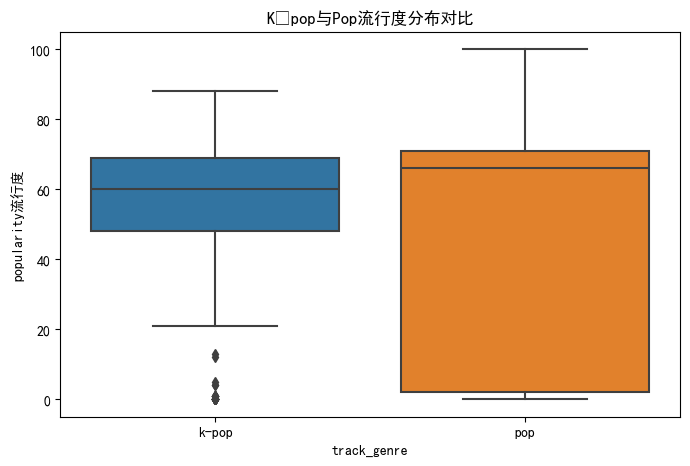

In [6]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df_compare, x="track_genre", y="popularity")
plt.title("K‑pop与Pop流行度分布对比")
plt.ylabel("popularity流行度")
plt.show()

In [7]:
#输出统计结果保存为csv文件
stat_result.to_csv("kpop_pop_feature_compare.csv",encoding="utf‑8‑sig")
print("统计结果文件已保存到本地文件夹")

统计结果文件已保存到本地文件夹
